# Fragment Length Frequency and Rescaling

This notebook provides the implementation for analyzing DNA fragment length distributions and rescaling them to match a reference distribution. The analysis is divided into two main parts:

1. **Fragment Length Frequency**: Calculate and plot the normalized frequency distribution of DNA fragment lengths
2. **Rescaling**: Subsample the query data to match a reference distribution

## Setup and Imports

First, let's import all the necessary libraries for our analysis.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
import requests
from collections import Counter
import seaborn as sns
import random

# Set the plot style
plt.style.use('ggplot')

## Part 1: Fragment Length Frequency

In this part, we'll calculate the distribution of fragment lengths from a BED file and plot the normalized frequency.

### Loading and Processing the BED File

We'll parse the BED file to calculate fragment lengths. Each fragment length is the difference between the end and start positions (3rd column - 2nd column).

In [18]:
# Function to parse the BED file and calculate fragment lengths
def parse_bed_file(filename):
    fragment_lengths = []
    
    with gzip.open(filename, 'rt') as file:
        for line in file:
            fields = line.strip().split()
            if len(fields) >= 3:  # Ensure we have at least 3 columns
                start = int(fields[1])
                end = int(fields[2])
                fragment_length = end - start
                fragment_lengths.append(fragment_length)
                
    return fragment_lengths

# Parse the local file and calculate fragment lengths
fragment_lengths = parse_bed_file('query.bed.gz')

# Display basic statistics about the fragment lengths
print(f"Total number of fragments: {len(fragment_lengths)}")
print(f"Minimum fragment length: {min(fragment_lengths)}")
print(f"Maximum fragment length: {max(fragment_lengths)}")
print(f"Mean fragment length: {np.mean(fragment_lengths):.2f}")
print(f"Median fragment length: {np.median(fragment_lengths):.2f}")

Total number of fragments: 13835737
Minimum fragment length: 24
Maximum fragment length: 700
Mean fragment length: 104.91
Median fragment length: 94.00


### Calculating Fragment Length Frequencies

Now we'll count the occurrence of each fragment length and normalize the frequencies.

In [4]:
# Count the frequency of each fragment length
length_counts = Counter(fragment_lengths)

# Convert to DataFrame for easier processing
df_lengths = pd.DataFrame({
    'fragment_length': list(length_counts.keys()),
    'count': list(length_counts.values())
})

# Sort by fragment length
df_lengths = df_lengths.sort_values('fragment_length').reset_index(drop=True)

# Calculate normalized frequencies
total_count = sum(length_counts.values())
df_lengths['normalized_frequency'] = df_lengths['count'] / total_count

print(f"Number of unique fragment lengths: {len(df_lengths)}")
print(f"Total count of fragments: {total_count}")
df_lengths.head()

Number of unique fragment lengths: 677
Total count of fragments: 13835737


,fragment_length,count,normalized_frequency
0,24,366,0.000026
1,25,1600,0.000116
2,26,2153,0.000156
3,27,2552,0.000184
4,28,2944,0.000213


### Visualizing Fragment Length Distribution

Let's plot the normalized frequency distribution of fragment lengths.

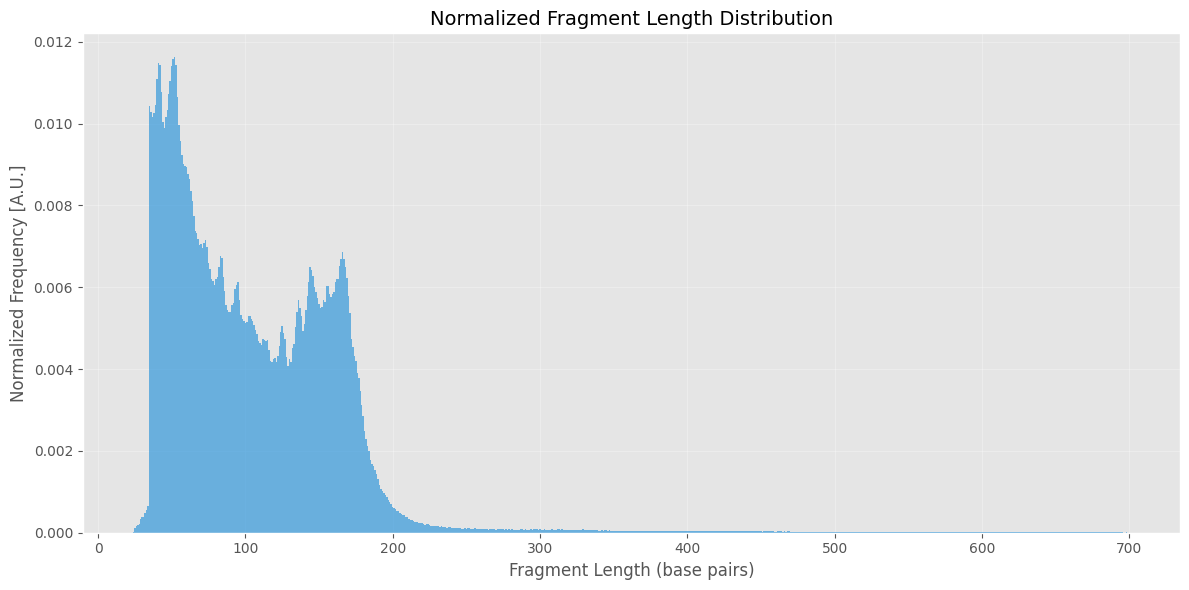

In [5]:
plt.figure(figsize=(12, 6))
plt.bar(df_lengths['fragment_length'], df_lengths['normalized_frequency'], 
        width=1, alpha=0.7, color='#3498db')
plt.xlabel('Fragment Length (base pairs)', fontsize=12)
plt.ylabel('Normalized Frequency [A.U.]', fontsize=12)
plt.title('Normalized Fragment Length Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Let's also create a smoother visualization using a line plot with KDE (Kernel Density Estimation):

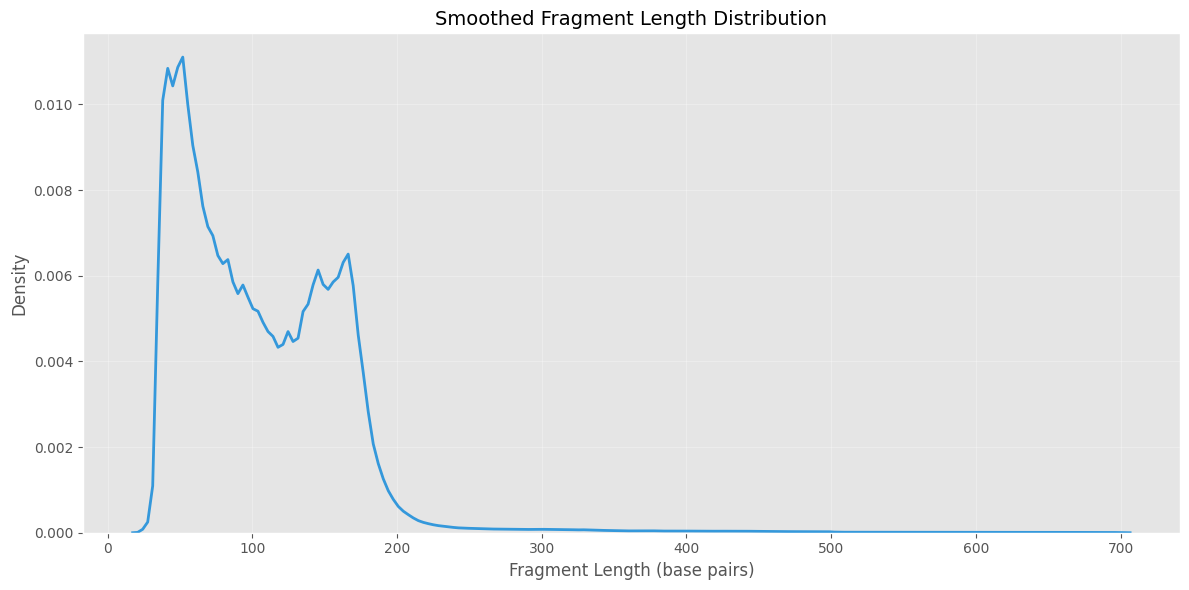

In [6]:
plt.figure(figsize=(12, 6))

# Create expanded dataframe for smoothing
expanded_data = []
for length, count in length_counts.items():
    expanded_data.extend([length] * count)

# Plot KDE
sns.kdeplot(expanded_data, color='#3498db', linewidth=2)
plt.xlabel('Fragment Length (base pairs)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Smoothed Fragment Length Distribution', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Rescaling

In this part, we'll rescale (subsample) our query data to match a reference distribution.

### Loading the Reference Distribution

First, we'll load the reference histogram file.

In [10]:
# Load the reference histogram from the local file
reference_data = pd.read_csv("reference.hist", sep='\t', header=None, 
                            names=['fragment_length', 'frequency'])

# Normalize the reference distribution
reference_data['normalized_frequency'] = reference_data['frequency'] / reference_data['frequency'].sum()

print("Reference distribution summary:")
print(f"Total count in reference: {reference_data['frequency'].sum()}")
print(f"Number of unique fragment lengths in reference: {len(reference_data)}")
reference_data.head()

Reference distribution summary:
Total count in reference: 0.999999999999981
Number of unique fragment lengths in reference: 677


,fragment_length,frequency,normalized_frequency
0,24,0.000013,0.000013
1,25,0.000063,0.000063
2,26,0.000092,0.000092
3,27,0.000117,0.000117
4,28,0.000136,0.000136


### Comparing Query and Reference Distributions

Let's visualize both distributions to see how they differ before rescaling.

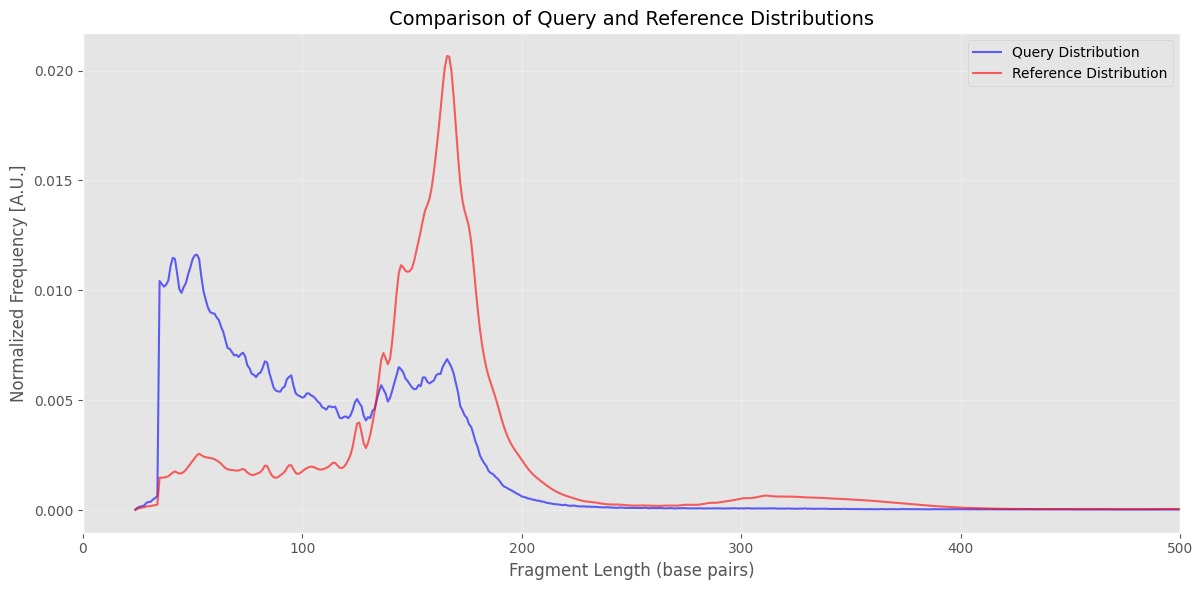

In [11]:
plt.figure(figsize=(12, 6))

# Plot query distribution
plt.plot(df_lengths['fragment_length'], df_lengths['normalized_frequency'], 
         color='blue', alpha=0.6, label='Query Distribution')

# Plot reference distribution
plt.plot(reference_data['fragment_length'], reference_data['normalized_frequency'], 
         color='red', alpha=0.6, label='Reference Distribution')

plt.xlabel('Fragment Length (base pairs)', fontsize=12)
plt.ylabel('Normalized Frequency [A.U.]', fontsize=12)
plt.title('Comparison of Query and Reference Distributions', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Zoom in to focus on the most informative region
plt.xlim(0, 500)  # Adjust as needed based on your data
plt.show()

In [ ]:
frag_by_length = {}   
for l in fragment_lengths:
    frag_by_length.setdefault(l, []).append(l)

length_freq = dict(length_counts)
total_fragments = sum(length_freq.values())
target_total = int(total_fragments * 0.3)

ref_freq_dict = dict(zip(reference_data['fragment_length'], reference_data['normalized_frequency']))

rescaled_fragments = []

for l, ref_freq in ref_freq_dict.items():
    if l in frag_by_length:

        desired_count = int(ref_freq * target_total)

        current_pool = frag_by_length[l]
        sampled = random.sample(current_pool, min(len(current_pool), desired_count))
        rescaled_fragments.extend(sampled)

rescaled_counts = Counter(rescaled_fragments)
total_rescaled = sum(rescaled_counts.values())
rescaled_freq = {i: j / total_rescaled for i, j in rescaled_counts.items()}


In [21]:
# Prepare data for plotting
# Sort the fragment lengths for query data
sorted_lengths = sorted(length_freq.keys())
sorted_freqs = [length_freq[k]/total_fragments for k in sorted_lengths]

# Reference data for plotting
ref_lengths = reference_data['fragment_length'].tolist()
ref_freqs = reference_data['normalized_frequency'].tolist()

# Prepare rescaled data for plotting
rescaled_x = sorted(rescaled_freq.keys())
rescaled_y = [rescaled_freq[k] for k in rescaled_x]


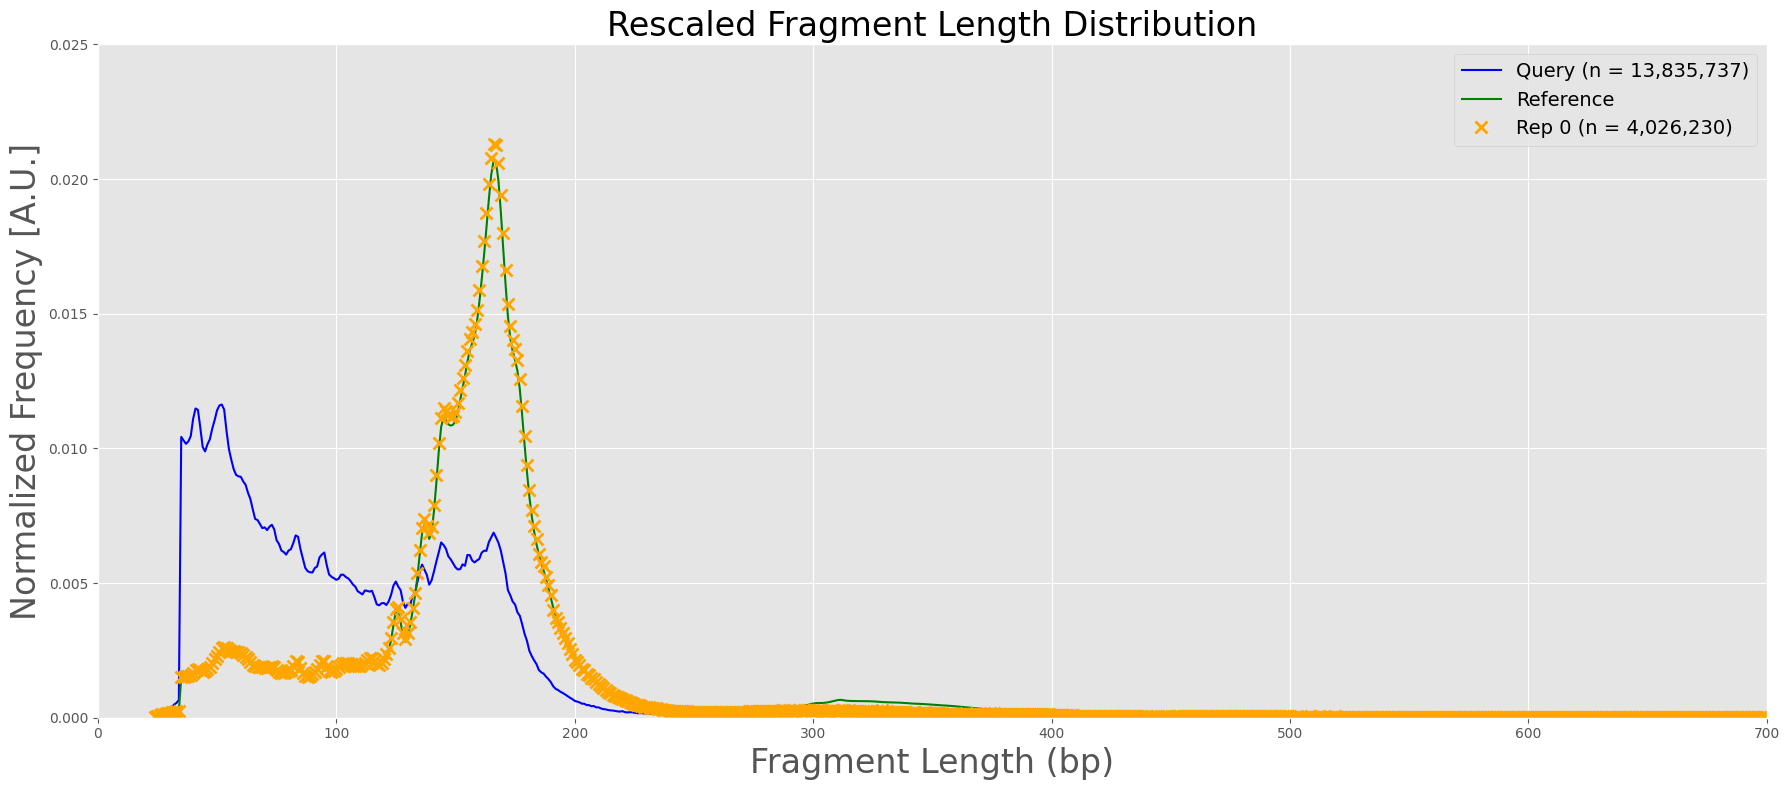

In [22]:
query_x, query_y = sorted_lengths, sorted_freqs
ref_x, ref_y = ref_lengths, ref_freqs
rescaled_x = sorted(rescaled_freq.keys())
rescaled_y = [rescaled_freq[k] for k in rescaled_x]

plt.figure(figsize=(18, 8))
plt.plot(query_x, query_y, label=f'Query (n = {total_fragments:,})', color='blue')
plt.plot(ref_x, ref_y, label='Reference', color='green')
plt.plot(rescaled_x, rescaled_y, 'x', label=f'Rep 0 (n = {total_rescaled:,})', color='orange', markersize=8, markeredgewidth=2)
plt.xlabel("Fragment Length (bp)", fontsize=24)
plt.ylabel("Normalized Frequency [A.U.]", fontsize=24)
plt.title("Rescaled Fragment Length Distribution", fontsize=24)
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("./rescaled_prediction.png")
plt.show()